In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [76]:
# import lic and zambia data
lic_eco = pd.read_csv("../data/LIC_EconomicPerformance/LIC_eco_perform.csv")
zambia_eco = pd.read_csv("../data/Zambia_EconomicPerformance/eco_perform.csv")

In [77]:
lic_clean, lic_lookup = clean_wb_wide(lic_eco)
zambia_clean, zambia_lookup = clean_wb_wide(zambia_eco)

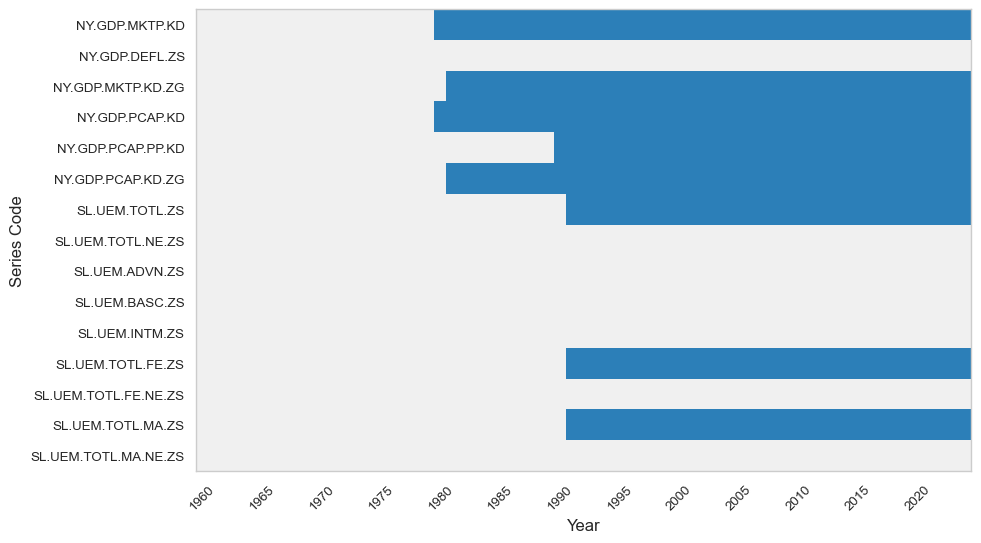

In [78]:
# plot missing data heatmap
availability, fig, ax = plot_missing_heatmap(
    lic_clean,
    lookup=lic_lookup,
)

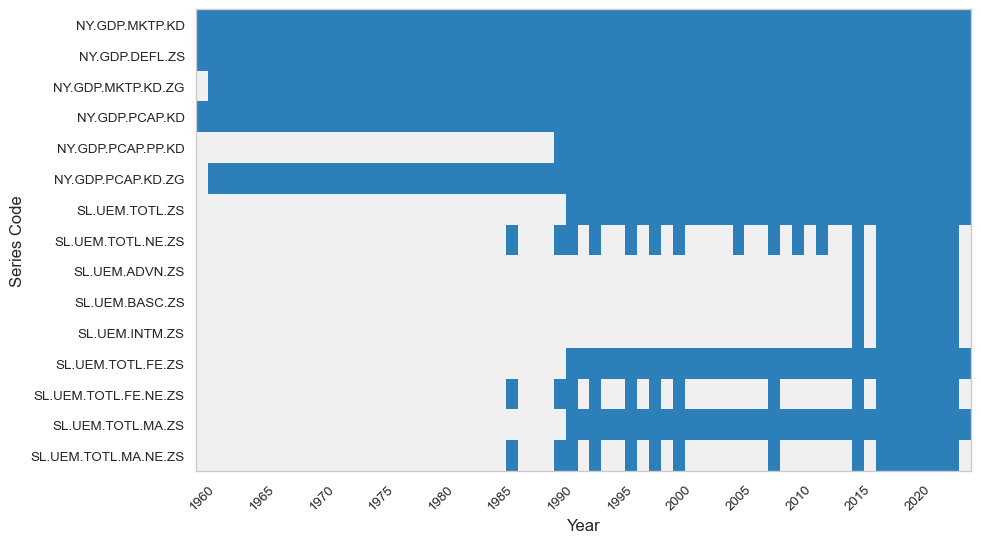

In [79]:
availability, fig, ax = plot_missing_heatmap(
    zambia_clean,
    lookup=zambia_lookup,
)

## GDPPC PPP

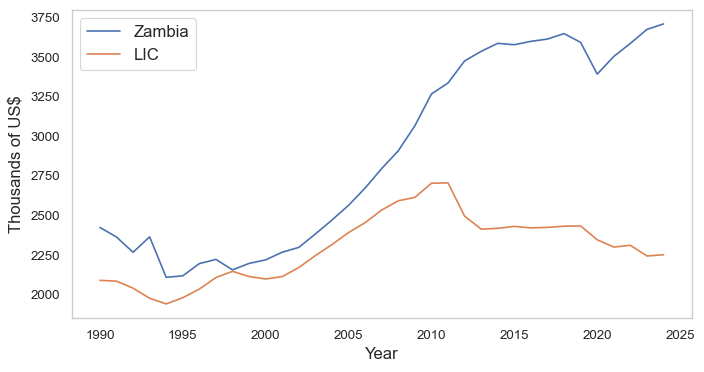

In [102]:
# zambia
df_zambia = zambia_clean.dropna(subset=['NY.GDP.PCAP.PP.KD'])
df_lic = lic_clean.dropna(subset=['NY.GDP.PCAP.PP.KD'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_zambia['Year'], df_zambia['NY.GDP.PCAP.PP.KD'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NY.GDP.PCAP.PP.KD'], label='LIC')
ax.legend(fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Thousands of US$', fontsize=12)
ax.grid(False)

fig.savefig(
    "../figures/LIC/eco_performance/GDPPC_PPP_zambia_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

## GDPPC growth

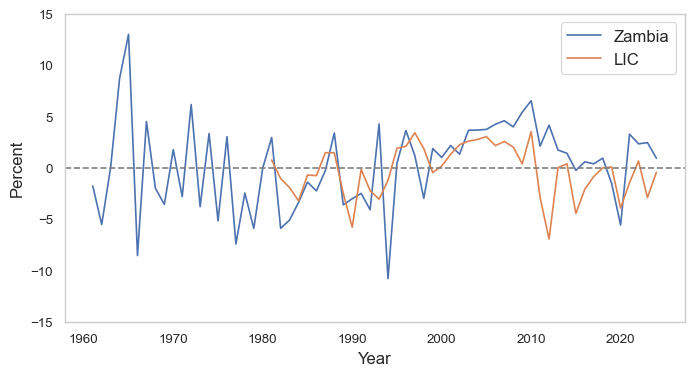

In [111]:
# zambia
df_zambia = zambia_clean.dropna(subset=['NY.GDP.PCAP.KD.ZG'])
df_lic = lic_clean.dropna(subset=['NY.GDP.PCAP.KD.ZG'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_zambia['Year'], df_zambia['NY.GDP.PCAP.KD.ZG'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NY.GDP.PCAP.KD.ZG'], label='LIC')
ax.legend(fontsize=12)
# dashed line for zero growth
ax.axhline(0, linestyle='--', color='grey')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent', fontsize=12)
ax.set_ylim(-15, 15)
ax.grid(False)

fig.savefig(
    "../figures/LIC/eco_performance/GDPPC_growth_annual_zambia_lic.pdf",
    format="pdf",
    bbox_inches="tight"
)

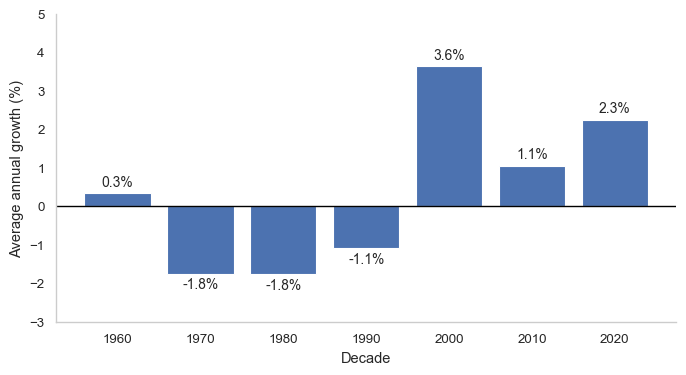

In [118]:
df = zambia_clean[['Year', 'NY.GDP.PCAP.KD']].dropna()
df = df.set_index('Year')

# define decade
df['decade'] = (df.index // 10) * 10

decadal_growth = []

for dec, group in df.groupby('decade'):
    if len(group) > 1:
        start = group.iloc[0]['NY.GDP.PCAP.KD']
        end = group.iloc[-1]['NY.GDP.PCAP.KD']
        n = len(group) - 1
        g = (end / start) ** (1/n) - 1
        decadal_growth.append((dec, g * 100))

decadal_growth = pd.DataFrame(decadal_growth, columns=['Decade', 'Growth'])

fig, ax = plt.subplots(figsize=(8,4))

ax.bar(decadal_growth['Decade'].astype(str),
       decadal_growth['Growth'])

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Decade')
ax.set_ylabel('Average annual growth (%)')

# show percentage on each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    else:
        ax.text(p.get_x() + p.get_width() / 2, height - 0.1,
                f'{height:.1f}%', ha='center', va='top', fontsize=10)

ax.set_ylim(-3, 5)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/eco_performance/GDPPC_growth_decade_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

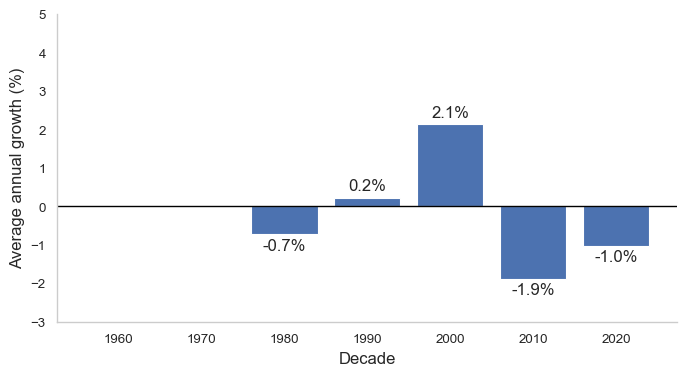

In [119]:
df = lic_clean[['Year', 'NY.GDP.PCAP.KD']].dropna()
df = df.set_index('Year')

# define decade
df['decade'] = (df.index // 10) * 10

decadal_growth = []

for dec, group in df.groupby('decade'):
    if len(group) > 1:
        start = group.iloc[0]['NY.GDP.PCAP.KD']
        end = group.iloc[-1]['NY.GDP.PCAP.KD']
        n = len(group) - 1
        g = (end / start) ** (1/n) - 1
        decadal_growth.append((dec, g * 100))

all_decades = [1960, 1970, 1980, 1990, 2000, 2010, 2020]

decadal_growth = (
    pd.DataFrame(decadal_growth, columns=['Decade', 'Growth'])
    .set_index('Decade')
    .reindex(all_decades)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,4))

x = np.arange(len(all_decades))
growth_plot = decadal_growth['Growth'].fillna(0)
bars = ax.bar(x, growth_plot)
ax.set_xticks(x)
ax.set_xticklabels(all_decades)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Average annual growth (%)', fontsize=12)

# show percentage on each bar
for bar, val in zip(bars, decadal_growth['Growth']):
    if pd.notna(val):  # only label real values
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=12)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, val - 0.1,
                    f'{val:.1f}%', ha='center', va='top', fontsize=12)

ax.set_ylim(-3, 5)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/eco_performance/GDPPC_growth_decade_LIC.pdf",
    format="pdf",
    bbox_inches="tight"
)

## Unemployment

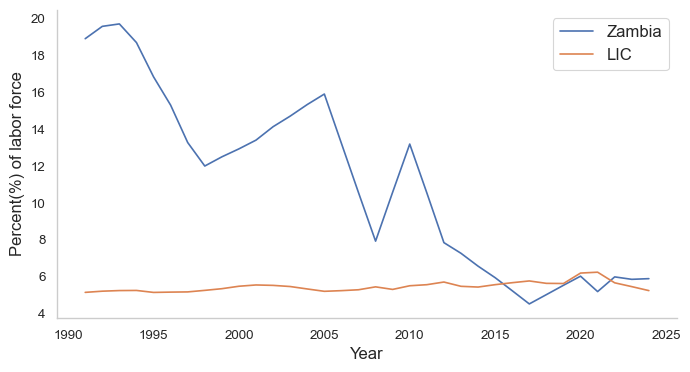

In [86]:
df_zambia = zambia_clean.set_index('Year')
df_lic = lic_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df_zambia.index, df_zambia['SL.UEM.TOTL.ZS'], label='Zambia')
ax.plot(df_lic.index, df_lic['SL.UEM.TOTL.ZS'], label= 'LIC')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent(%) of labor force', fontsize=12)

ax.legend(fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/LIC/eco_performance/unemployment_LIC_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

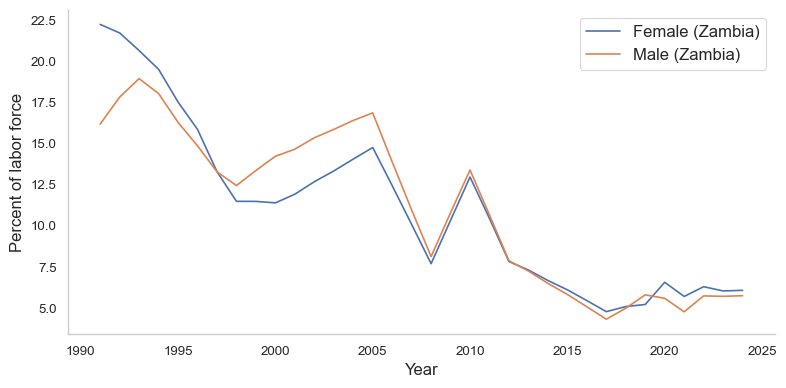

In [87]:
df_zambia = zambia_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_zambia.index, df_zambia['SL.UEM.TOTL.FE.ZS'], label='Female (Zambia)')
ax.plot(df_zambia.index, df_zambia['SL.UEM.TOTL.MA.ZS'], label='Male (Zambia)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent of labor force', fontsize=12)

# ---- Style ----
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=12)  # compact legend

plt.tight_layout()
fig.savefig(
    "../figures/LIC/eco_performance/UEM_gender_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

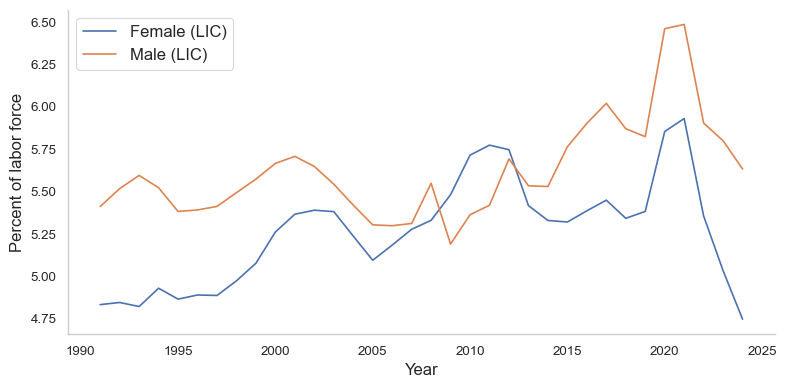

In [88]:
df = lic_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df.index, df['SL.UEM.TOTL.FE.ZS'], label='Female (LIC)')
ax.plot(df.index, df['SL.UEM.TOTL.MA.ZS'], label='Male (LIC)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent of labor force', fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=12)  # compact legend

plt.tight_layout()

fig.savefig(
    "../figures/LIC/eco_performance/UEM_gender_LIC.pdf",
    format="pdf",
    bbox_inches="tight"
)